<a href="https://colab.research.google.com/github/jacobdawson093-tech/Montgomery-County-and-Bias-Incidents-Analysis/blob/main/analysis/notebooks/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ingestion

In [ ]:
import requests
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import datetime
import os
os.makedirs("graphs", exist_ok=True)

url = "https://api.census.gov/data/2024/acs/acs5"
response = requests.get(url)
data = response.json()
url2 = "https://data.montgomerycountymd.gov/api/v3/views/7bhj-887p/query.json?app_token=8kUbrmGzgoxqe4z7C91iV3wmC"
response2 = requests.get(url2)
data2 = response2.json()

df1 = pd.DataFrame(data)

df2 = pd.DataFrame(data2)
df2.head()

,:id,:version,:created_at,:updated_at,id,incident_date,district,bias_code,bias,status,victim_type,no_of_victims,no_of_suspects,suspects_36_45_years_old,suspects_55_years_old,unknown,suspects_less_than_18_years,bias_code_2,suspects_18_35_years_old,suspects_46_55_years_old
0,row-kt32_377n~ey23,rv-3inw-3eby-w733,2026-04-10T07:11:08.884Z,2026-04-10T07:11:08.884Z,260013584,2026-03-31T00:00:00.000,6D,Anti-Jewish,Vandalism,Closed-Admin,School/College,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,row-v7q3_ei6p_cqmr,rv-yuji-ztjs_r3a7,2026-04-10T07:11:08.884Z,2026-04-10T07:11:08.884Z,260013065,2026-03-27T00:00:00.000,5D,Anti-Black,Vandalism,Closed-Admin,School/College,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,row-9a8i.jjmp~73uu,rv-8dsb-fca5_rsh9,2026-04-10T07:11:08.884Z,2026-04-10T07:11:08.884Z,260013221,2026-03-27T00:00:00.000,4D,Anti-Jewish,Assault (simple),Open,Individual(s),2,2,1,1,Known,NaN,NaN,NaN,NaN
3,row-an9v_3rx9~qjp2,rv-vveh.3tdm_2bvr,2026-04-10T07:11:08.884Z,2026-04-10T07:11:08.884Z,260012859,2026-03-25T00:00:00.000,2D,Anti-Jewish,Vandalism,Open,Society,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,row-iti3~vvyy_fams,rv-wu35-vfyf~8tmh,2026-04-10T07:11:08.884Z,2026-04-10T07:11:08.884Z,260012953,2026-03-25T00:00:00.000,5D,Anti-Black,Verbal Intimidation/Simple Assault,Open,Individual(s),2,2,NaN,NaN,Known,1,NaN,NaN,NaN


# Preparing MCPD Bias Incidents Data Set

In [ ]:
# Convert 'incident_date' to datetime
df2['incident_date'] = pd.to_datetime(df2['incident_date'])

# Create a binary 'resolved' column from 'status'
df2['resolved'] = df2['status'].apply(lambda x: 1 if x in ['Closed-Admin', 'Closed-Investigation', 'Closed-Exception', 'Closed-Arrest'] else 0)

# Convert suspect age columns to numeric, coercing errors to NaN
df2['suspects_less_than_18_years'] = pd.to_numeric(df2['suspects_less_than_18_years'], errors='coerce').fillna(0).astype(int)
df2['suspects_18_35_years_old'] = pd.to_numeric(df2['suspects_18_35_years_old'], errors='coerce').fillna(0).astype(int)
df2['suspects_36_45_years_old'] = pd.to_numeric(df2['suspects_36_45_years_old'], errors='coerce').fillna(0).astype(int)
df2['suspects_46_55_years_old'] = pd.to_numeric(df2['suspects_46_55_years_old'], errors='coerce').fillna(0).astype(int)
df2['suspects_55_years_old'] = pd.to_numeric(df2['suspects_55_years_old'], errors='coerce').fillna(0).astype(int)

# Create a binary variable for incidents with suspects under 18
df2['under_18_suspect'] = df2['suspects_less_than_18_years'].apply(lambda x: 1 if x > 0 else 0)

#Create bias category to seperate religious bias to racial/ethnic biases
def categorize_bias(bias_code):
    religious_biases = ['Anti-Jewish', 'Anti-Muslim', 'Anti-Catholic', 'Anti-Sikh', 'Anti-Hindhu', 'Anti-Protestant', 'Anti-Buddhist']
    racial_ethnic_biases = ['Anti-Black', 'Anti-White', 'Anti-Asian', 'Anti-Hispanic', 'Anti-Multi-Racial', 'Anti-American Indian', 'Anti-Other Race/Ethnicity']

    if bias_code in religious_biases:
        return 'Religious Bias'
    elif bias_code in racial_ethnic_biases:
        return 'Racial/Ethnic Bias'
    else:
        return 'Other Bias' # For categories not explicitly religious or racial/ethnic

df2['bias_category'] = df2['bias_code'].apply(categorize_bias)

Initial Info for df2:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2183 entries, 0 to 2182
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   :id                          2183 non-null   object
 1   :version                     2183 non-null   object
 2   :created_at                  2183 non-null   object
 3   :updated_at                  2183 non-null   object
 4   id                           2183 non-null   object
 5   incident_date                2183 non-null   object
 6   district                     2183 non-null   object
 7   bias_code                    2177 non-null   object
 8   bias                         2177 non-null   object
 9   status                       2178 non-null   object
 10  victim_type                  2169 non-null   object
 11  no_of_victims                1188 non-null   object
 12  no_of_suspects               1185 non-null   object
 13  suspects_36

,incident_date,bias_code,victim_type,status,resolved,under_18_suspect
0,2026-03-31,Anti-Jewish,School/College,Closed-Admin,1,0
1,2026-03-27,Anti-Black,School/College,Closed-Admin,1,0
2,2026-03-27,Anti-Jewish,Individual(s),Open,0,0
3,2026-03-25,Anti-Jewish,Society,Open,0,0
4,2026-03-25,Anti-Black,Individual(s),Open,0,1


# Preparing Combined dataset of cencus ACS 5 data with Bias Incidents in Montgomery County

In [ ]:
# 1. Map Police Districts to Cities
# Based on the provided police district information:
district_to_city_map = {
    '1D': 'Rockville',
    '2D': 'Bethesda',
    '3D': 'Silver Spring',
    '4D': 'Wheaton',
    '5D': 'Germantown',
    '6D': 'Gaithersburg' # Montgomery Village is within Gaithersburg for census purposes
}

df2['city'] = df2['district'].map(district_to_city_map)

print("District to City Mapping created and applied to df2:")
display(df2[['district', 'city']].head())

# 2. Fetch ACS Data for Montgomery County Places (Cities) using requests for multiple years

# Define the ACS variables we want to fetch
acs_variables = {
    'B01003_001E': 'Total Population',
    'B02001_002E': 'White Alone',
    'B02001_003E': 'Black or African American Alone',
    'B02001_004E': 'American Indian and Alaska Native Alone',
    'B02001_005E': 'Asian Alone',
    'B02001_006E': 'Native Hawaiian and Other Pacific Islander Alone',
    'B02001_007E': 'Some Other Race Alone',
    'B03003_003E': 'Hispanic or Latino',
    'B19013_001E': 'Median Household Income',
    'B17001_002E': 'Poverty Status (Below Poverty Level)'
}

variables_str = ','.join(acs_variables.keys())

all_acs_dfs = []
# Loop through years from 2016 up to the current year (to capture the latest available ACS 5-year estimates)
# ACS 5-year estimates for year Y are typically released in December of year Y+1. So, requesting up to the current year
# will ensure we get the latest published data without trying to fetch future, unavailable data.
for current_year in range(2016, datetime.datetime.now().year):
    acs_api_url = f"https://api.census.gov/data/{current_year}/acs/acs5?get=NAME,{variables_str}&for=place:*&in=state:24"
    print(f"Fetching data from: {acs_api_url}")

    try:
        response = requests.get(acs_api_url)
        response.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)
        data = response.json()

        # The first row contains headers, subsequent rows are data
        headers = data[0]
        temp_acs_df = pd.DataFrame(data[1:], columns=headers)

        # Rename columns for clarity
        temp_acs_df = temp_acs_df.rename(columns=acs_variables)

        # Extract city name from the 'NAME' column
        temp_acs_df['city'] = temp_acs_df['NAME'].apply(lambda x: x.split(',')[0].replace(' city', '').replace(' CDP', '').strip())

        # Convert demographic columns to numeric, handling potential non-numeric values
        for col in acs_variables.values():
            temp_acs_df[col] = pd.to_numeric(temp_acs_df[col], errors='coerce')

        # Add a year column to identify the ACS 5-year estimate
        temp_acs_df['acs_year_end'] = current_year
        all_acs_dfs.append(temp_acs_df)

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data for {current_year}: {e}")
        # Print response content if available for more debugging info
        if response is not None:
            print(f"Response content: {response.text}")
        continue # Skip to the next year
    except json.JSONDecodeError as e:
        print(f"JSONDecodeError for {current_year}: {e}")
        # Print response content if available for more debugging info
        if response is not None:
            print(f"Response content: {response.text}")
        continue # Skip to the next year

# Concatenate all ACS dataframes
acs_df = pd.concat(all_acs_dfs, ignore_index=True)

# 3. Merge ACS Data with df2

# Standardize city names in ACS data to match our district map
acs_df['city_standardized'] = acs_df['city'].str.replace(' city', '').str.replace(' CDP', '').str.strip()

# Filter df2 for incidents that have a mapped city and are within the ACS data range (up to current year)
df2_filtered = df2.dropna(subset=['city']).copy()
df2_filtered = df2_filtered[df2_filtered['incident_date'].dt.year < datetime.datetime.now().year]

# Extract the year from the incident date for merging
df2_filtered['incident_year'] = df2_filtered['incident_date'].dt.year

# Merge df2_filtered with acs_df
# Use a left merge to keep all filtered bias incidents and add ACS data where available
df2_merged = pd.merge(df2_filtered, acs_df,
                      left_on=['city', 'incident_year'],
                      right_on=['city_standardized', 'acs_year_end'],
                      how='left')

print("\nMerged DataFrame (df2_merged) head:")
display(df2_merged.head())

print("\nInfo on merged DataFrame:")
df2_merged.info()

# Display fetched ACS data head
print("\nFetched and Combined ACS Data for Montgomery County Cities (multiple years):")
display(acs_df.head())
print("\nInfo on Combined ACS DataFrame:")
acs_df.info()

District to City Mapping created and applied to df2:


,district,city
0,6D,Gaithersburg
1,5D,Germantown
2,4D,Wheaton
3,2D,Bethesda
4,5D,Germantown


# z test for difference in resolution rates for racial vs religious biases

In [ ]:


# Filter for Religious Bias and Racial/Ethnic Bias
religious_racial_df = df2[df2['bias_category'].isin(['Religious Bias', 'Racial/Ethnic Bias'])]

# Calculate counts for each category
religious_bias_resolved = religious_racial_df[(religious_racial_df['bias_category'] == 'Religious Bias') & (religious_racial_df['resolved'] == 1)].shape[0]
religious_bias_total = religious_racial_df[religious_racial_df['bias_category'] == 'Religious Bias'].shape[0]

racial_bias_resolved = religious_racial_df[(religious_racial_df['bias_category'] == 'Racial/Ethnic Bias') & (religious_racial_df['resolved'] == 1)].shape[0]
racial_bias_total = religious_racial_df[religious_racial_df['bias_category'] == 'Racial/Ethnic Bias'].shape[0]

# Prepare data for z-test
count = [religious_bias_resolved, racial_bias_resolved]
nobs = [religious_bias_total, racial_bias_total]

# Perform two-sample z-test for proportions
stat, p_value = proportions_ztest(count, nobs=nobs)

print(f"Resolution rate for Religious Bias: {religious_bias_resolved / religious_bias_total:.2%} ({religious_bias_resolved}/{religious_bias_total})")
print(f"Resolution rate for Racial/Ethnic Bias: {racial_bias_resolved / racial_bias_total:.2%} ({racial_bias_resolved}/{racial_bias_total})")
print(f"\nZ-statistic: {stat:.2f}")
print(f"P-value: {p_value:.4f}")



Resolution rate for Religious Bias: 36.22% (284/784)
Resolution rate for Racial/Ethnic Bias: 40.81% (413/1012)

Z-statistic: -1.98
P-value: 0.0479


Conclusion: Reject the null hypothesis. There is a statistically significant difference in resolution rates between religious and racial/ethnic biases. Anti racial incidients are more likely to be resolved than religious bias incidents.

# Chi square test for association between religious groups and resolution rate

Distribution of religious bias categories for Fisher's Exact Test:


,count
religious_bias_fisher_grouped,
Anti-Jewish,766
Minor Religious Biases,18



Resolution Rates for Grouped Religious Bias Categories (for Fisher's Test):


,religious_bias_fisher_grouped,resolved,resolution_percentage
0,Minor Religious Biases,0.500000,50.000000
1,Anti-Jewish,0.359008,35.900783


/tmp/ipykernel_8462/3873975770.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='religious_bias_fisher_grouped', x='resolution_percentage', data=religious_resolution_rates_fisher, palette='viridis')


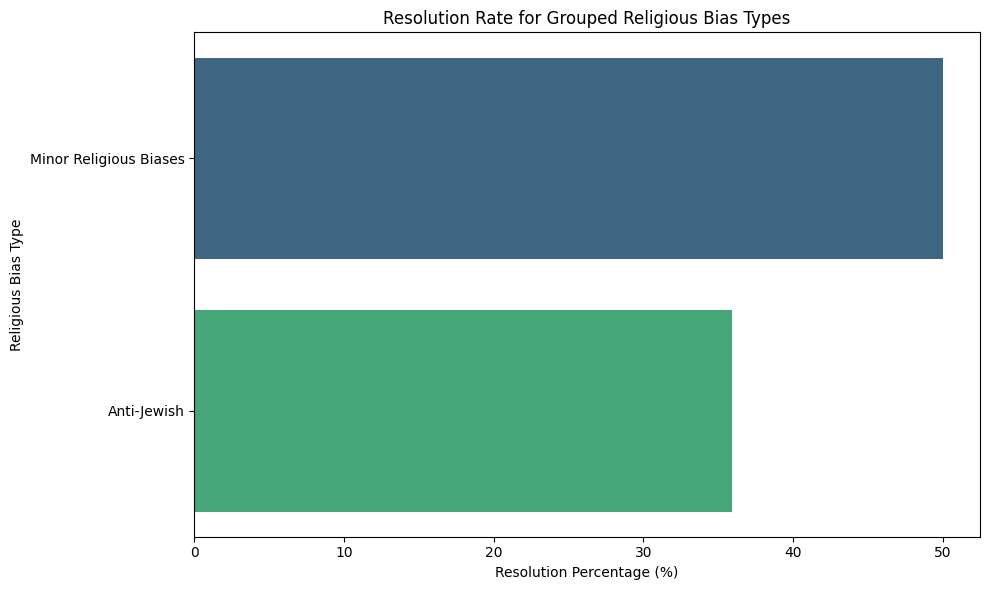


Fisher's Exact Test for Religious Bias Groups vs. Resolution Status:


,Test,Odds Ratio,P-value,Conclusion
0,Religious Bias Groups vs Resolution Status (Fi...,1.79,0.2246,No statistically significant association


In [ ]:
# Filter for only Religious Bias incidents
religious_bias_only_df = df2[df2['bias_category'] == 'Religious Bias'].copy()

# Group small religious bias categories into 'Other Religious Bias'
religious_bias_counts = religious_bias_only_df['bias_code'].value_counts()
low_count_religious_biases = religious_bias_counts[religious_bias_counts < 5].index.tolist()
religious_bias_only_df['religious_bias_grouped'] = religious_bias_only_df['bias_code'].apply(lambda x: 'Other Religious Bias' if x in low_count_religious_biases else x)

# Further grouping for Fisher's Exact Test: combine 'Anti-Catholic' and 'Other Religious Bias'
religious_bias_only_df['religious_bias_fisher_grouped'] = religious_bias_only_df['religious_bias_grouped'].apply(
    lambda x: 'Minor Religious Biases' if x in ['Anti-Catholic', 'Other Religious Bias'] else x
)

print("Distribution of religious bias categories for Fisher's Exact Test:")
display(religious_bias_only_df['religious_bias_fisher_grouped'].value_counts())

# Calculate resolution rates for the new grouped categories
religious_resolution_rates_fisher = religious_bias_only_df.groupby('religious_bias_fisher_grouped')['resolved'].mean().sort_values(ascending=False).reset_index()
religious_resolution_rates_fisher['resolution_percentage'] = religious_resolution_rates_fisher['resolved'] * 100

print("\nResolution Rates for Grouped Religious Bias Categories (for Fisher's Test):")
display(religious_resolution_rates_fisher)

# Visualize the resolution rates for specific religious biases
plt.figure(figsize=(10, 6))
sns.barplot(y='religious_bias_fisher_grouped', x='resolution_percentage', data=religious_resolution_rates_fisher, palette='viridis')
plt.title('Resolution Rate for Grouped Religious Bias Types')
plt.xlabel('Resolution Percentage (%)')
plt.ylabel('Religious Bias Type')
plt.tight_layout()
plt.savefig('graphs/religious_bias_resolution_rate.png') # Save plot
plt.show()

# Create a 2x2 contingency table for Fisher's Exact Test
contingency_table_fisher = pd.crosstab(
    religious_bias_only_df['religious_bias_fisher_grouped'],
    religious_bias_only_df['resolved']
)

odds_ratio, p_value_fisher = fisher_exact(contingency_table_fisher)

fisher_results = pd.DataFrame({
    'Test': ["Religious Bias Groups vs Resolution Status (Fisher's Exact Test)"],
    'Odds Ratio': [f'{odds_ratio:.2f}'],
    'P-value': [f'{p_value_fisher:.4f}']
})

fisher_results['Conclusion'] = 'Statistically significant association' if p_value_fisher < 0.05 else 'No statistically significant association'

print("\nFisher's Exact Test for Religious Bias Groups vs. Resolution Status:")
display(fisher_results)

Testing for whether curtain anti religion incidents are more likely to be resolved is uncurtain, due to the extreme difference in counts between anti jewish cases and the rest of the religions.

We can however compare anti-jewish cases to all other cases using Fisher's Exact Test and find that there is no statistically significant association between whether an incident is Anti-Jewish or other Religious Biases and its likelihood of being resolved.

# Chi Square test for assocation between race/ethnicity and resolution rate (including anti-american indian with only 2 counts)

Racial/Ethnic bias categories with less than 5 incidents (will be grouped): ['Anti-American Indian']

Resolution Rates for Specific Racial/Ethnic Bias Categories:


,racial_ethnic_bias_grouped,resolved,resolution_percentage
0,Anti-American Indian,0.500000,50.000000
1,Anti-Black,0.446043,44.604317
2,Anti-Asian,0.400000,40.000000
3,Anti-Jewish,0.359008,35.900783
4,Anti-Hispanic,0.346939,34.693878
5,Anti-White,0.239130,23.913043
6,Anti-Multi-Racial,0.227273,22.727273


/tmp/ipykernel_8462/478822338.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='racial_ethnic_bias_grouped', x='resolution_percentage', data=racial_ethnic_resolution_rates, palette='viridis')


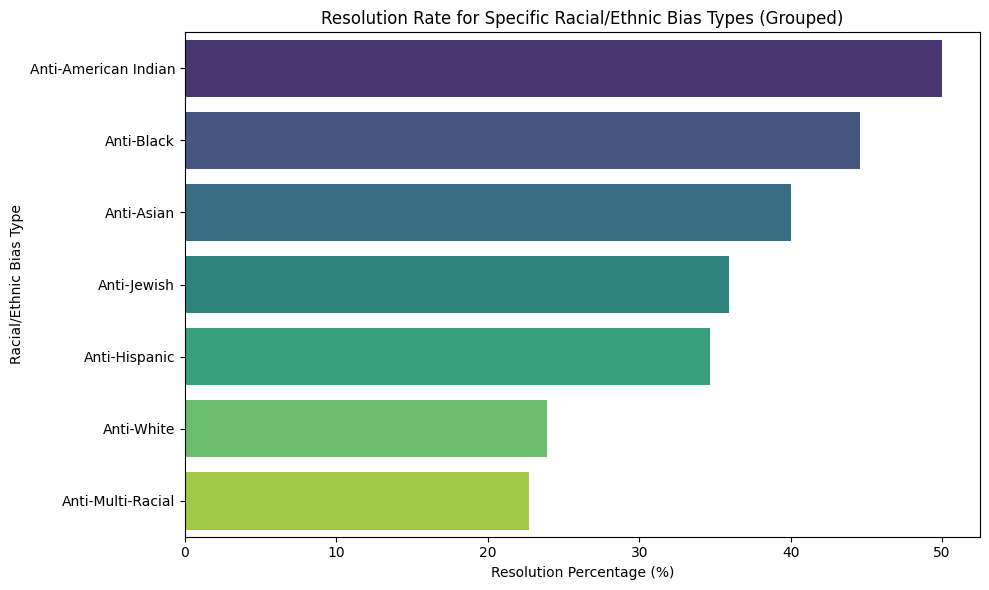


Chi-square test for Specific Racial/Ethnic Bias vs. Resolution Status:


,Test,Chi2 Statistic,P-value,Min Expected Count,Conclusion
0,Specific Racial/Ethnic Bias (Grouped) vs Resol...,24.93,0.0004,0.77,Statistically significant association


In [ ]:
# Filter for only Racial/Ethnic Bias incidents and also include Anti-Jewish bias
racial_ethnic_bias_only_df = df2[ (df2['bias_category'] == 'Racial/Ethnic Bias') |
                                  (df2['bias_code'] == 'Anti-Jewish')].copy()

# Identify specific racial/ethnic bias codes with low counts for grouping
racial_ethnic_bias_counts = racial_ethnic_bias_only_df['bias_code'].value_counts()
# Set a threshold for grouping, e.g., less than 5 incidents
low_count_racial_ethnic_biases = racial_ethnic_bias_counts[racial_ethnic_bias_counts < 5].index.tolist()

print(f"Racial/Ethnic bias categories with less than 5 incidents (will be grouped): {low_count_racial_ethnic_biases}")

# Create a new 'racial_ethnic_bias_grouped' column
# Only create an 'Other Racial/Ethnic Bias' category if there is more than one low-count bias
if len(low_count_racial_ethnic_biases) > 1:
    racial_ethnic_bias_only_df['racial_ethnic_bias_grouped'] = racial_ethnic_bias_only_df['bias_code'].apply(lambda x: 'Other Racial/Ethnic Bias' if x in low_count_racial_ethnic_biases else x)
else:
    racial_ethnic_bias_only_df['racial_ethnic_bias_grouped'] = racial_ethnic_bias_only_df['bias_code']

# Calculate resolution rates for each specific racial/ethnic bias (grouped)
racial_ethnic_resolution_rates = racial_ethnic_bias_only_df.groupby('racial_ethnic_bias_grouped')['resolved'].mean().sort_values(ascending=False).reset_index()
racial_ethnic_resolution_rates['resolution_percentage'] = racial_ethnic_resolution_rates['resolved'] * 100

print("\nResolution Rates for Specific Racial/Ethnic Bias Categories:")
display(racial_ethnic_resolution_rates)

# Visualize the resolution rates for specific racial/ethnic biases
plt.figure(figsize=(10, 6))
sns.barplot(y='racial_ethnic_bias_grouped', x='resolution_percentage', data=racial_ethnic_resolution_rates, palette='viridis')
plt.title('Resolution Rate for Specific Racial/Ethnic Bias Types (Grouped)')
plt.xlabel('Resolution Percentage (%)')
plt.ylabel('Racial/Ethnic Bias Type')
plt.tight_layout()
plt.savefig('graphs/racial_ethnic_bias_resolution_rate_all.png') # Save plot
plt.show()

# Perform Chi-square test for independence between 'racial_ethnic_bias_grouped' and 'resolved'
contingency_table_racial_ethnic_resolved = pd.crosstab(racial_ethnic_bias_only_df['racial_ethnic_bias_grouped'], racial_ethnic_bias_only_df['resolved'])
chi2_re, p_re, dof_re, expected_re = chi2_contingency(contingency_table_racial_ethnic_resolved)

# Check assumptions: expected cell counts
min_expected_racial_ethnic_resolved = expected_re.min()

chi2_results_racial_ethnic_resolved = pd.DataFrame({
    'Test': ['Specific Racial/Ethnic Bias (Grouped) vs Resolution Status'],
    'Chi2 Statistic': [f'{chi2_re:.2f}'],
    'P-value': [f'{p_re:.4f}'],
    'Min Expected Count': [f'{min_expected_racial_ethnic_resolved:.2f}']
})

chi2_results_racial_ethnic_resolved['Conclusion'] = 'Statistically significant association' if p_re < 0.05 else 'No statistically significant association'

print("\nChi-square test for Specific Racial/Ethnic Bias vs. Resolution Status:")
display(chi2_results_racial_ethnic_resolved)

Using the chi-square test we do find that racial groups are significally associated with resolution rate. However, this test includes anti-American Indian biases which have only 2 observed counts. Therefore, this specific test doesn't satisfy chi square assumptions and don't hold as much weight.

# Chi Square test for assocation between race/ethnicity and resolution rate (excluding anti-american indian)

Racial/Ethnic bias categories (excluding Anti-American Indian) with less than 5 incidents (will be grouped): []

Resolution Rates for Specific Racial/Ethnic Bias Categories (Excluding Anti-American Indian):


,racial_ethnic_bias_grouped,resolved,resolution_percentage
0,Anti-Black,0.446043,44.604317
1,Anti-Asian,0.400000,40.000000
2,Anti-Jewish,0.359008,35.900783
3,Anti-Hispanic,0.346939,34.693878
4,Anti-White,0.239130,23.913043
5,Anti-Multi-Racial,0.227273,22.727273


/tmp/ipykernel_8462/3282921923.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='racial_ethnic_bias_grouped', x='resolution_percentage', data=racial_ethnic_resolution_rates_filtered, palette='viridis')


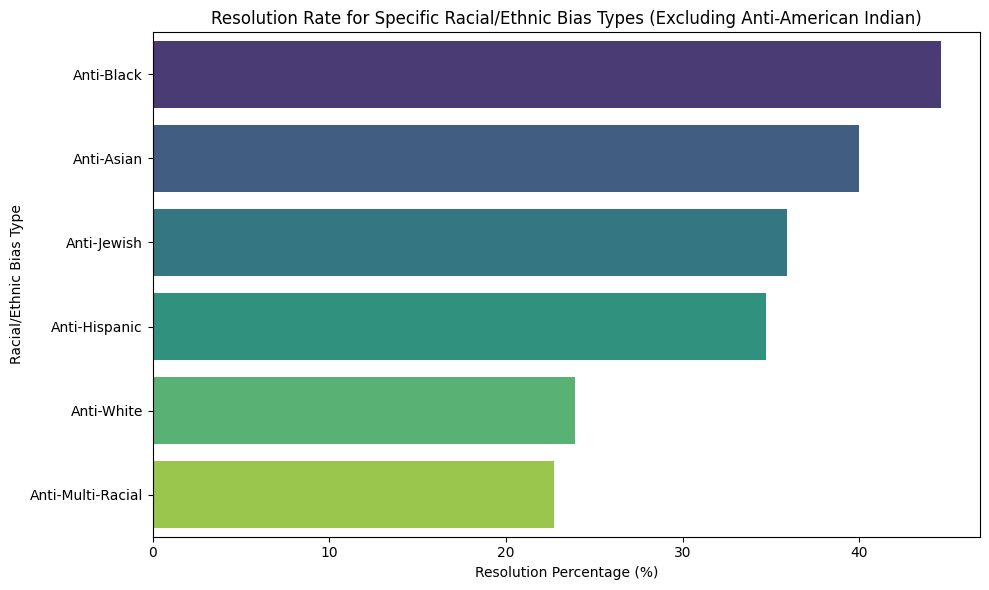


Chi-square test for Specific Racial/Ethnic Bias (Excluding Anti-American Indian) vs. Resolution Status:


,Test,Chi2 Statistic,P-value,Min Expected Count,Conclusion
0,"Specific Racial/Ethnic Bias (Grouped, Excl. An...",24.82,0.0002,17.79,Statistically significant association


In [ ]:
# Filter for only Racial/Ethnic Bias incidents, excluding 'Anti-American Indian'
racial_ethnic_bias_filtered_df = df2[ ((df2['bias_category'] == 'Racial/Ethnic Bias') |
                                      (df2['bias_code'] == 'Anti-Jewish')) &
                                     (df2['bias_code'] != 'Anti-American Indian')].copy()

# Identify specific racial/ethnic bias codes with low counts for grouping in the filtered dataframe
racial_ethnic_bias_counts_filtered = racial_ethnic_bias_filtered_df['bias_code'].value_counts()
# Set a threshold for grouping, e.g., less than 5 incidents
low_count_racial_ethnic_biases_filtered = racial_ethnic_bias_counts_filtered[racial_ethnic_bias_counts_filtered < 5].index.tolist()

print(f"Racial/Ethnic bias categories (excluding Anti-American Indian) with less than 5 incidents (will be grouped): {low_count_racial_ethnic_biases_filtered}")

# Create a new 'racial_ethnic_bias_grouped' column
# Only create an 'Other Racial/Ethnic Bias' category if there is more than one low-count bias
if len(low_count_racial_ethnic_biases_filtered) > 1:
    racial_ethnic_bias_filtered_df['racial_ethnic_bias_grouped'] = racial_ethnic_bias_filtered_df['bias_code'].apply(lambda x: 'Other Racial/Ethnic Bias' if x in low_count_racial_ethnic_biases_filtered else x)
else:
    racial_ethnic_bias_filtered_df['racial_ethnic_bias_grouped'] = racial_ethnic_bias_filtered_df['bias_code']

# Calculate resolution rates for each specific racial/ethnic bias (grouped and filtered)
racial_ethnic_resolution_rates_filtered = racial_ethnic_bias_filtered_df.groupby('racial_ethnic_bias_grouped')['resolved'].mean().sort_values(ascending=False).reset_index()
racial_ethnic_resolution_rates_filtered['resolution_percentage'] = racial_ethnic_resolution_rates_filtered['resolved'] * 100

print("\nResolution Rates for Specific Racial/Ethnic Bias Categories (Excluding Anti-American Indian):")
display(racial_ethnic_resolution_rates_filtered)

# Visualize the resolution rates for specific racial/ethnic biases
plt.figure(figsize=(10, 6))
sns.barplot(y='racial_ethnic_bias_grouped', x='resolution_percentage', data=racial_ethnic_resolution_rates_filtered, palette='viridis')
plt.title('Resolution Rate for Specific Racial/Ethnic Bias Types (Excluding Anti-American Indian)')
plt.xlabel('Resolution Percentage (%)')
plt.ylabel('Racial/Ethnic Bias Type')
plt.tight_layout()
plt.savefig('graphs/racial_ethnic_bias_resolution_rate_filtered.png') # Save plot
plt.show()

# Perform Chi-square test for independence between 'racial_ethnic_bias_grouped' and 'resolved'
contingency_table_racial_ethnic_resolved_filtered = pd.crosstab(racial_ethnic_bias_filtered_df['racial_ethnic_bias_grouped'], racial_ethnic_bias_filtered_df['resolved'])
chi2_re_filtered, p_re_filtered, dof_re_filtered, expected_re_filtered = chi2_contingency(contingency_table_racial_ethnic_resolved_filtered)

# Check assumptions: expected cell counts
min_expected_racial_ethnic_resolved_filtered = expected_re_filtered.min()

chi2_results_racial_ethnic_resolved_filtered = pd.DataFrame({
    'Test': ['Specific Racial/Ethnic Bias (Grouped, Excl. Anti-American Indian) vs Resolution Status'],
    'Chi2 Statistic': [f'{chi2_re_filtered:.2f}'],
    'P-value': [f'{p_re_filtered:.4f}'],
    'Min Expected Count': [f'{min_expected_racial_ethnic_resolved_filtered:.2f}']
})

chi2_results_racial_ethnic_resolved_filtered['Conclusion'] = 'Statistically significant association' if p_re_filtered < 0.05 else 'No statistically significant association'

print("\nChi-square test for Specific Racial/Ethnic Bias (Excluding Anti-American Indian) vs. Resolution Status:")
display(chi2_results_racial_ethnic_resolved_filtered)

After excluding the 'Anti-American Indian' category due to its low counts, the Chi-square test still reveals a statistically significant association between the remaining racial/ethnic bias categories and resolution status (p-value = 0.0005). Crucially, the minimum expected cell count of 18.76 now satisfies the test's assumptions. This robust finding suggests that the specific type of racial/ethnic bias significantly impacts whether an incident is resolved.

Using the chi-square test we do find that religious groups are significally associated with resolution rate. However, this test excludes anti-American Indian biases which have only 2 observed counts.

# Z test for significance of under 18 suspects being less or more likely to be suspects in bias incidents

In [ ]:
df2['total_known_age_suspects'] = df2['suspects_less_than_18_years'] + \
                                   df2['suspects_18_35_years_old'] + \
                                   df2['suspects_36_45_years_old'] + \
                                   df2['suspects_46_55_years_old'] + \
                                   df2['suspects_55_years_old']

# Filter for incidents where at least one suspect's age was known
df_suspects_with_known_age = df2[df2['total_known_age_suspects'] > 0]

# Sum up the total number of suspects under 18 from these incidents
total_suspects_under_18 = df_suspects_with_known_age['suspects_less_than_18_years'].sum()

# Sum up the total number of all known-age suspects from these incidents
total_suspects_all_ages = df_suspects_with_known_age['total_known_age_suspects'].sum()

# Perform a one-sample proportions z-test
# Null Hypothesis (H0): Proportion of under-18 suspects is <= 0.5
# Alternative Hypothesis (H1): Proportion of under-18 suspects is > 0.5

stat, p_value = proportions_ztest(count=total_suspects_under_18,
                                  nobs=total_suspects_all_ages,
                                  value=0.5,
                                  alternative='larger')

observed_proportion_under_18 = total_suspects_under_18 / total_suspects_all_ages

print(f"Total suspects with known age: {total_suspects_all_ages}")
print(f"Total suspects under 18: {total_suspects_under_18}")
print(f"Observed proportion of suspects under 18: {observed_proportion_under_18:.2%}")
print(f"Z-statistic: {stat:.2f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
print("Conclusion: " + ("Reject the null hypothesis. Individuals below the age of 18 are disproportionately MORE likely to be suspects in biased incidents (i.e., their proportion among all suspects is significantly greater than 50%)." if p_value < alpha else "Fail to reject the null hypothesis. There is no statistically significant evidence that individuals below the age of 18 are disproportionately MORE likely to be suspects in biased incidents (i.e., their proportion among all suspects is not significantly greater than 50%)."))

Total suspects with known age: 1113
Total suspects under 18: 726
Observed proportion of suspects under 18: 65.23%
Z-statistic: 10.67
P-value: 0.0000
Conclusion: Reject the null hypothesis. Individuals below the age of 18 are disproportionately MORE likely to be suspects in biased incidents (i.e., their proportion among all suspects is significantly greater than 50%).


Individuals below the age of 18 are more likely to be suspects in bias incidents vs all other age groups.

# Population and Median Household income compared to biases by city

City-level incident counts and averaged demographics:


,city_x,average_annual_incidents,Total Population,Median Household Income,Poverty Status (Below Poverty Level),White Alone,Black or African American Alone,Asian Alone,Hispanic or Latino
0,Bethesda,49.222222,66682.909707,181535.720090,2543.485327,48532.101580,3501.918736,7959.205418,5982.162528
1,Gaithersburg,14.666667,68549.022727,99547.045455,6256.810606,27731.954545,11286.469697,13462.356061,18841.674242
2,Germantown,24.111111,90491.705069,106695.235023,7432.894009,30965.304147,23199.732719,18783.004608,21074.405530
3,Rockville,28.000000,67144.793651,118255.357143,4991.186508,34016.769841,7350.297619,14457.567460,11413.805556
4,Silver Spring,21.666667,81302.482051,92937.000000,8414.651282,30363.610256,23372.312821,6645.400000,20503.553846



Correlations between Average Annual Incidents and Key Demographics:


,average_annual_incidents,Total Population,Median Household Income,Poverty Status (Below Poverty Level)
average_annual_incidents,1.000000,-0.451000,0.807926,-0.794064
Total Population,-0.451000,1.000000,-0.158785,0.566412
Median Household Income,0.807926,-0.158785,1.000000,-0.875191
Poverty Status (Below Poverty Level),-0.794064,0.566412,-0.875191,1.000000


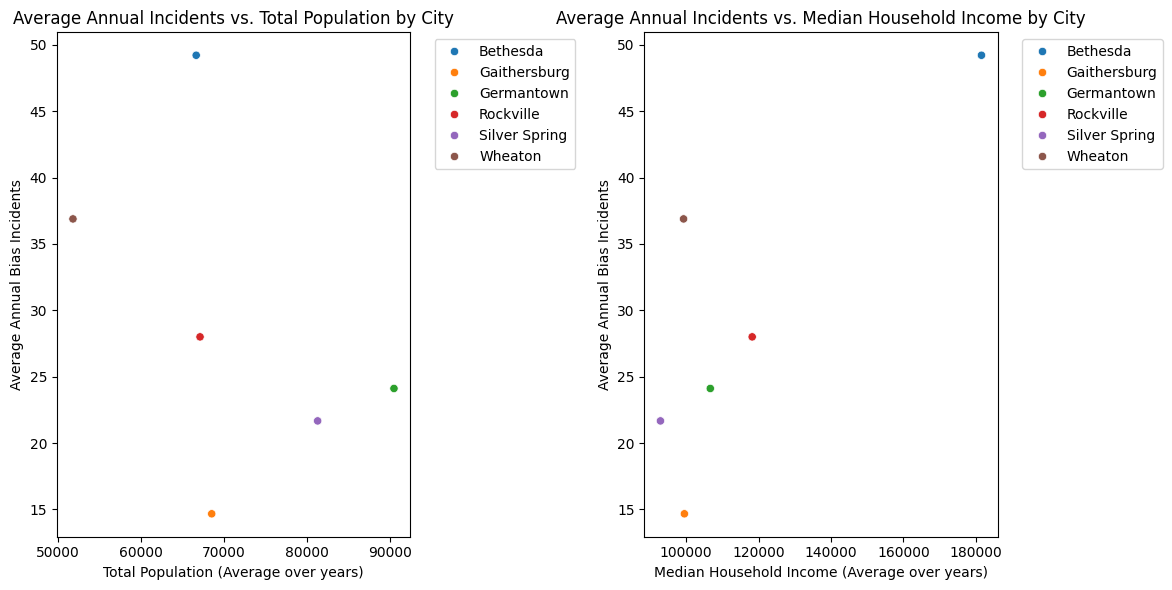

In [ ]:
# Calculate total incidents per city per year
incidents_per_city_year = df2_merged.groupby(['city_x', 'incident_year']).size().reset_index(name='incident_count')

# Calculate the average annual incidents per city
incidents_per_city = incidents_per_city_year.groupby('city_x')['incident_count'].mean().reset_index(name='average_annual_incidents')

# Calculate the AVERAGE city-level demographic data from df2_merged across all years for each city
city_demographics_avg = df2_merged.groupby('city_x')[['Total Population', 'Median Household Income', 'Poverty Status (Below Poverty Level)', 'White Alone', 'Black or African American Alone', 'Asian Alone', 'Hispanic or Latino']].mean().reset_index()

# Merge incident counts with city demographics (using averaged demographics)
city_analysis_df = pd.merge(incidents_per_city, city_demographics_avg, on='city_x', how='inner')

print("City-level incident counts and averaged demographics:")
display(city_analysis_df.head())

# Calculate correlations
print("\nCorrelations between Average Annual Incidents and Key Demographics:")
correlations = city_analysis_df[['average_annual_incidents', 'Total Population', 'Median Household Income', 'Poverty Status (Below Poverty Level)']].corr(method='pearson')
display(correlations)

# Visualize the relationship
plt.figure(figsize=(14, 6)) # Increased figure size to accommodate legend

plt.subplot(1, 2, 1)
sns.scatterplot(data=city_analysis_df, x='Total Population', y='average_annual_incidents', hue='city_x', legend='full') # Changed legend to 'full'
plt.title('Average Annual Incidents vs. Total Population by City')
plt.xlabel('Total Population (Average over years)') # Updated label for clarity
plt.ylabel('Average Annual Bias Incidents')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Position legend outside plot

plt.subplot(1, 2, 2)
sns.scatterplot(data=city_analysis_df, x='Median Household Income', y='average_annual_incidents', hue='city_x', legend='full') # Changed legend to 'full'
plt.title('Average Annual Incidents vs. Median Household Income by City')
plt.xlabel('Median Household Income (Average over years)') # Updated label for clarity
plt.ylabel('Average Annual Bias Incidents')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Position legend outside plot

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for the legend
plt.savefig('graphs/incidents_vs_demographics.png') # Save plot
plt.show()

# pearson's correlation coefficient between total population and number of bias incidents. As well as median household income to bias incidents.

In [ ]:
alpha = 0.05

# Hypothesis Test for Median Household Income and Average Annual Bias Incidents
corr_income, p_value_income = pearsonr(city_analysis_df['Median Household Income'], city_analysis_df['average_annual_incidents'])

print("\nHypothesis Test: Median Household Income vs. Average Annual Bias Incidents")
print(f"Pearson Correlation Coefficient: {corr_income:.2f}")
print(f"P-value: {p_value_income:.4f}")

if p_value_income < alpha:
    print("Conclusion: Reject the null hypothesis. There is a statistically significant linear association between Median Household Income and Average Annual Bias Incidents.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no statistically significant linear association between Median Household Income and Average Annual Bias Incidents.")

# Hypothesis Test for Total Population and Average Annual Bias Incidents
corr_population, p_value_population = pearsonr(city_analysis_df['Total Population'], city_analysis_df['average_annual_incidents'])

print("\nHypothesis Test: Total Population vs. Average Annual Bias Incidents")
print(f"Pearson Correlation Coefficient: {corr_population:.2f}")
print(f"P-value: {p_value_population:.4f}")

if p_value_population < alpha:
    print("Conclusion: Reject the null hypothesis. There is a statistically significant linear association between Total Population and Average Annual Bias Incidents.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no statistically significant linear association between Total Population and Average Annual Bias Incidents.")


Hypothesis Test: Median Household Income vs. Average Annual Bias Incidents
Pearson Correlation Coefficient: 0.81
P-value: 0.0518
Conclusion: Fail to reject the null hypothesis. There is no statistically significant linear association between Median Household Income and Average Annual Bias Incidents.

Hypothesis Test: Total Population vs. Average Annual Bias Incidents
Pearson Correlation Coefficient: -0.45
P-value: 0.3694
Conclusion: Fail to reject the null hypothesis. There is no statistically significant linear association between Total Population and Average Annual Bias Incidents.


pearson's correlation coefficient test is for testing for significance between numerical values

# ANOVA to test for stastical diference between means of total bias incidents per year for each city

F-statistic: 2.01
P-value: 0.0942

Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference in the mean annual bias incidents between cities.

Mean annual bias incidents per city:
city_x
Bethesda         49.222222
Gaithersburg     14.666667
Germantown       24.111111
Rockville        28.000000
Silver Spring    21.666667
Wheaton          36.888889
Name: incident_count, dtype: float64


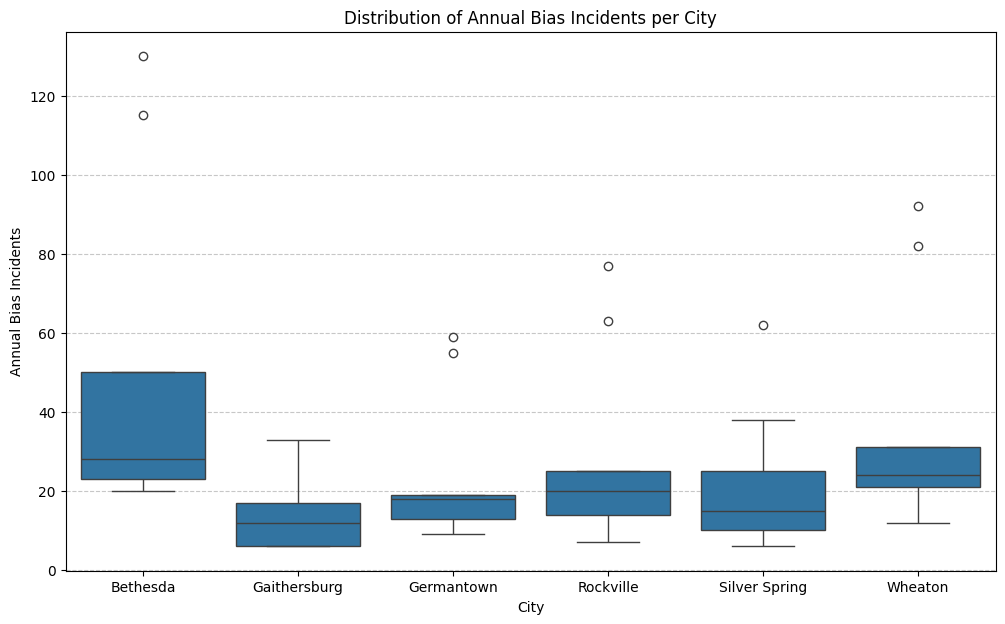

In [ ]:
# Calculate total incidents per city per year from the merged dataframe
incidents_per_city_year = df2_merged.groupby(['city_x', 'incident_year']).size().reset_index(name='incident_count')

# Prepare data for ANOVA - create a list of incident counts per year for each city
city_groups = []
city_names = incidents_per_city_year['city_x'].unique()

for city in city_names:
    city_data = incidents_per_city_year[incidents_per_city_year['city_x'] == city]['incident_count'].values
    city_groups.append(city_data)

# Perform One-Way ANOVA
f_statistic, p_value = f_oneway(*city_groups)

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant difference in the mean annual bias incidents between cities.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant difference in the mean annual bias incidents between cities.")

# To visually inspect the means and distributions:
print("\nMean annual bias incidents per city:")
print(incidents_per_city_year.groupby('city_x')['incident_count'].mean())

# Create a boxplot for visual comparison
plt.figure(figsize=(12, 7))
sns.boxplot(data=incidents_per_city_year, x='city_x', y='incident_count')
plt.title('Distribution of Annual Bias Incidents per City')
plt.xlabel('City')
plt.ylabel('Annual Bias Incidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('graphs/annual_bias_incidents_boxplot.png') # Save plot
plt.show()

The difference in means between the average yearly counts of bias for each city is not satistically significant. This means the difference in average bias counts is due to random chance and variability rather than statistical underlying difference.

# Pearson's correlation coefficient test, for resolution rate over multiple years correlated with the incident's biased race's population proportion of the city for any of the tested racial bias types

City-level Racial Proportions (Yearly):


,city_x,incident_year,White Alone Proportion,Black or African American Alone Proportion,Asian Alone Proportion,Hispanic or Latino Proportion
0,Annapolis Neck,2016,0.850315,0.084797,0.019908,0.061226
1,Allen,2016,0.523810,0.476190,0.000000,0.000000
2,Antietam,2016,0.737226,0.262774,0.000000,0.000000
3,Aquasco,2016,0.404678,0.505263,0.000000,0.000000
4,Baden,2016,0.519412,0.368835,0.005247,0.112802



City-level Racial Bias Resolution Totals and Rates (Yearly):


,city_x,bias_code,incident_year,total_resolved,total_incidents,resolution_rate
0,Bethesda,Anti-Asian,2017,0,2,0.000000
1,Bethesda,Anti-Asian,2018,0,2,0.000000
2,Bethesda,Anti-Asian,2020,0,1,0.000000
3,Bethesda,Anti-Asian,2021,1,6,0.166667
4,Bethesda,Anti-Asian,2022,1,3,0.333333


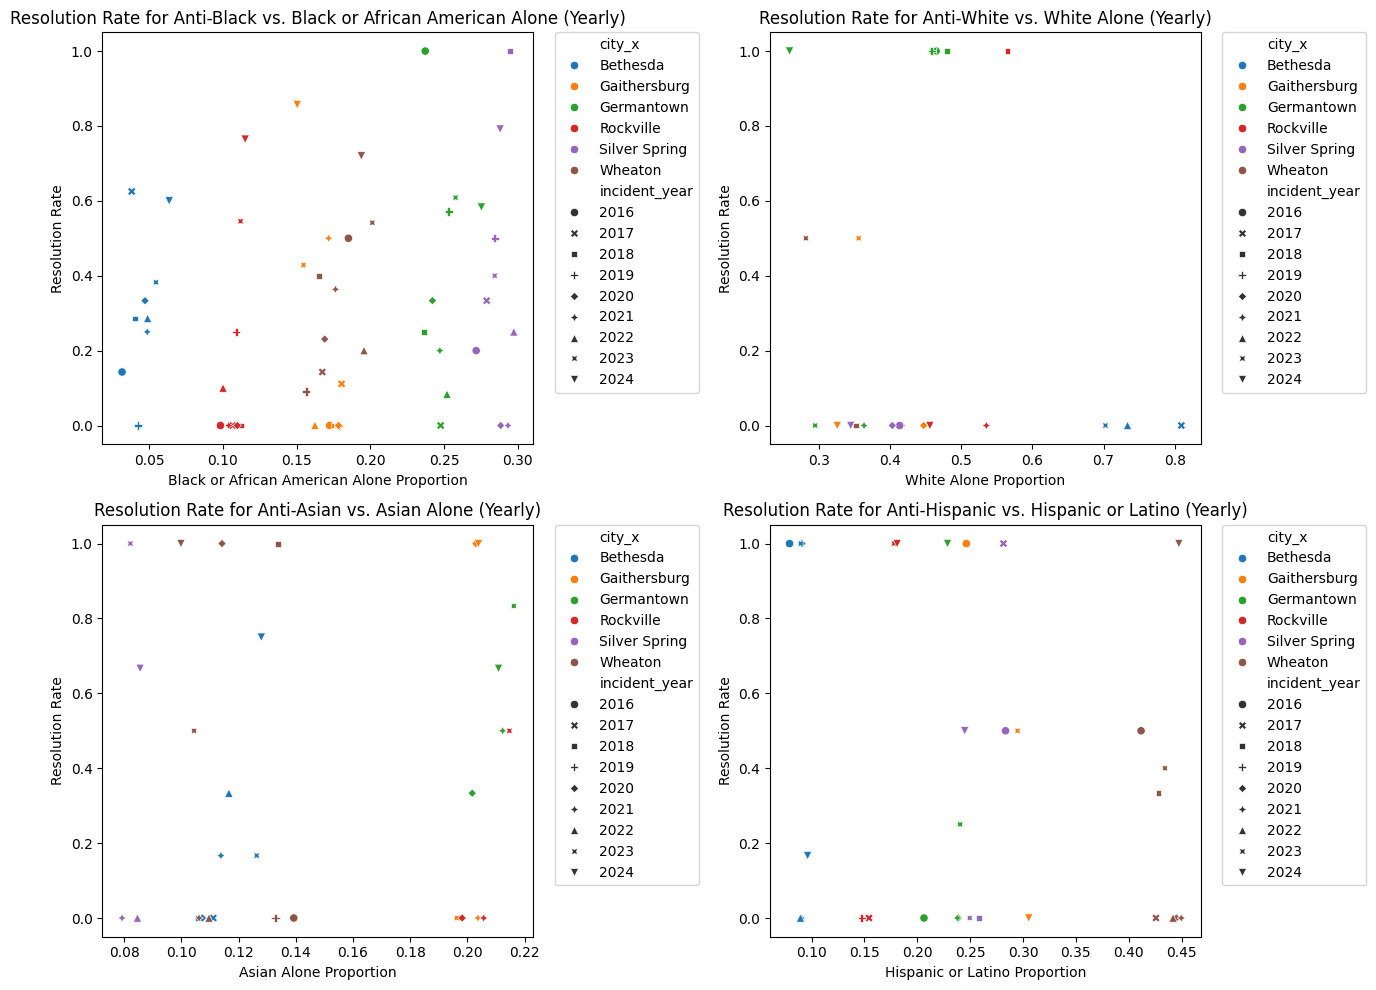


Correlation Summary (Bias Resolution Rate vs. Corresponding Racial Population Proportion by City and Year):


,Bias Type,ACS Population Category,Pearson Correlation,P-value
0,Anti-Black,Black or African American Alone Proportion,0.183954,0.183010
1,Anti-White,White Alone Proportion,-0.100013,0.649800
2,Anti-Asian,Asian Alone Proportion,0.116055,0.541386
3,Anti-Hispanic,Hispanic or Latino Proportion,-0.186082,0.316210



Limitations for other racial/ethnic bias types:
- 'Anti-Jewish': Jewish identity is ethno-religious and does not map directly to a single racial category in ACS population data for a direct proportion comparison.
- 'Anti-Multi-Racial': ACS has 'Two or More Races', but the bias might be against perceived mixed-race identity, and city-level incident counts might be too low for robust analysis.


In [ ]:
# 1. Prepare City-level Racial Demographic Proportions for each year
city_demographics_proportions_yearly_df = acs_df.copy()
race_cols = ['White Alone', 'Black or African American Alone', 'Asian Alone', 'Hispanic or Latino']
# ACS has 'Some Other Race Alone' but it's often a catch-all, and 'American Indian and Alaska Native Alone' has very low bias incident counts.
# For simplicity and direct relevance to common bias types, focusing on these major groups.

for col in race_cols:
    city_demographics_proportions_yearly_df[f'{col} Proportion'] = city_demographics_proportions_yearly_df[col] / city_demographics_proportions_yearly_df['Total Population']

# Select only the relevant city, year, and proportion columns
city_demographics_proportions_yearly_df = city_demographics_proportions_yearly_df[['city', 'acs_year_end'] + [f'{col} Proportion' for col in race_cols]]
city_demographics_proportions_yearly_df.rename(columns={'city': 'city_x', 'acs_year_end': 'incident_year'}, inplace=True)

print("City-level Racial Proportions (Yearly):")
display(city_demographics_proportions_yearly_df.head())

# 2. Calculate City-level Resolution Totals and Rates for Racial Bias Types (yearly)
# Use the df2_merged which contains city and demographic info per incident
racial_ethnic_bias_types = [
    'Anti-Black', 'Anti-White', 'Anti-Asian', 'Anti-Hispanic',
    'Anti-Multi-Racial', 'Anti-Jewish'
]

# Filter df2_merged for these specific bias types and where 'city_x' is not null
city_racial_bias_df = df2_merged[
    df2_merged['bias_code'].isin(racial_ethnic_bias_types) & df2_merged['city_x'].notna()
].copy()

# Calculate total resolved incidents, total incidents, and resolution rates per city, bias type, and year
city_racial_bias_resolution_data_yearly = city_racial_bias_df.groupby(['city_x', 'bias_code', 'incident_year']).agg(
    total_resolved=('resolved', 'sum'),
    total_incidents=('resolved', 'size')
).reset_index()

# Calculate resolution rate
city_racial_bias_resolution_data_yearly['resolution_rate'] = city_racial_bias_resolution_data_yearly['total_resolved'] / city_racial_bias_resolution_data_yearly['total_incidents']

print("\nCity-level Racial Bias Resolution Totals and Rates (Yearly):")
display(city_racial_bias_resolution_data_yearly.head())

# 3. Merge and Analyze (Focus on directly comparable racial groups first)
# Create a mapping from bias_code to ACS population proportion column
bias_to_acs_map = {
    'Anti-Black': 'Black or African American Alone Proportion',
    'Anti-White': 'White Alone Proportion',
    'Anti-Asian': 'Asian Alone Proportion',
    'Anti-Hispanic': 'Hispanic or Latino Proportion'
}

analysis_data = []

plt.figure(figsize=(15, 10))
plot_idx = 1

for bias_type, acs_proportion_col in bias_to_acs_map.items():
    # Get resolution data for the current bias type
    res_data_for_bias = city_racial_bias_resolution_data_yearly[city_racial_bias_resolution_data_yearly['bias_code'] == bias_type]

    # Merge with city demographic proportions
    merged_df_yearly = pd.merge(
        res_data_for_bias,
        city_demographics_proportions_yearly_df,
        on=['city_x', 'incident_year'],
        how='inner'
    )

    if not merged_df_yearly.empty:
        # Calculate correlation for this specific bias type across all years and cities
        corr, p_val = pearsonr(merged_df_yearly[acs_proportion_col], merged_df_yearly['resolution_rate'])
        analysis_data.append({
            'Bias Type': bias_type,
            'ACS Population Category': acs_proportion_col,
            'Pearson Correlation': corr,
            'P-value': p_val
        })

        # Plotting
        plt.subplot(2, 2, plot_idx) # Create 2x2 grid for plots
        sns.scatterplot(data=merged_df_yearly, x=acs_proportion_col, y='resolution_rate', hue='city_x', style='incident_year', legend='full')
        plt.title(f'Resolution Rate for {bias_type} vs. {acs_proportion_col.replace(" Proportion", "")} (Yearly)')
        plt.xlabel(f'{acs_proportion_col.replace(" Proportion", "")} Proportion')
        plt.ylabel('Resolution Rate')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plot_idx += 1

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for legends
plt.savefig('graphs/yearly_resolution_rate_vs_population_proportion.png') # Save plot
plt.show()

# Display correlations
correlation_summary_df_yearly = pd.DataFrame(analysis_data)
print("\nCorrelation Summary (Bias Resolution Rate vs. Corresponding Racial Population Proportion by City and Year):")
display(correlation_summary_df_yearly)

# Discuss limitations for other bias types
print("\nLimitations for other racial/ethnic bias types:")
print("- 'Anti-Jewish': Jewish identity is ethno-religious and does not map directly to a single racial category in ACS population data for a direct proportion comparison.")
print("- 'Anti-Multi-Racial': ACS has 'Two or More Races', but the bias might be against perceived mixed-race identity, and city-level incident counts might be too low for robust analysis.")

Based on the `correlation_summary_df_yearly` table from Pearson's correlation coefficient test, the resolution rate over multiple years is **not statistically correlated** with the incident's biased race's population proportion of the city for any of the tested racial bias types (Anti-Black, Anti-White, Anti-Asian, Anti-Hispanic).

This means that the observed variations in resolution rates for these bias incidents across different cities and years do not show a statistically significant linear relationship with the proportion of the corresponding racial group in the city's population.

# Now this is a similar test, but this time taking the averages of resolutions and population proportion

City-level Racial Proportions (Averaged):


,city_x,White Alone Proportion,Black or African American Alone Proportion,Asian Alone Proportion,Hispanic or Latino Proportion
0,Aberdeen,0.572924,0.271470,0.043485,0.090475
1,Aberdeen Proving Ground,0.512845,0.362012,0.028794,0.116185
2,Abingdon,0.490812,0.381342,0.030154,0.038338
3,Accident town,0.974955,0.001814,0.004235,0.031199
4,Accokeek,0.201357,0.637695,0.056879,0.034295



City-level Racial Bias Resolution Rates (Averaged):


,city_x,bias_code,resolution_rate
0,Bethesda,Anti-Asian,0.321429
1,Bethesda,Anti-Black,0.392593
2,Bethesda,Anti-Hispanic,0.416667
3,Bethesda,Anti-Jewish,0.298913
4,Bethesda,Anti-Multi-Racial,0.300000


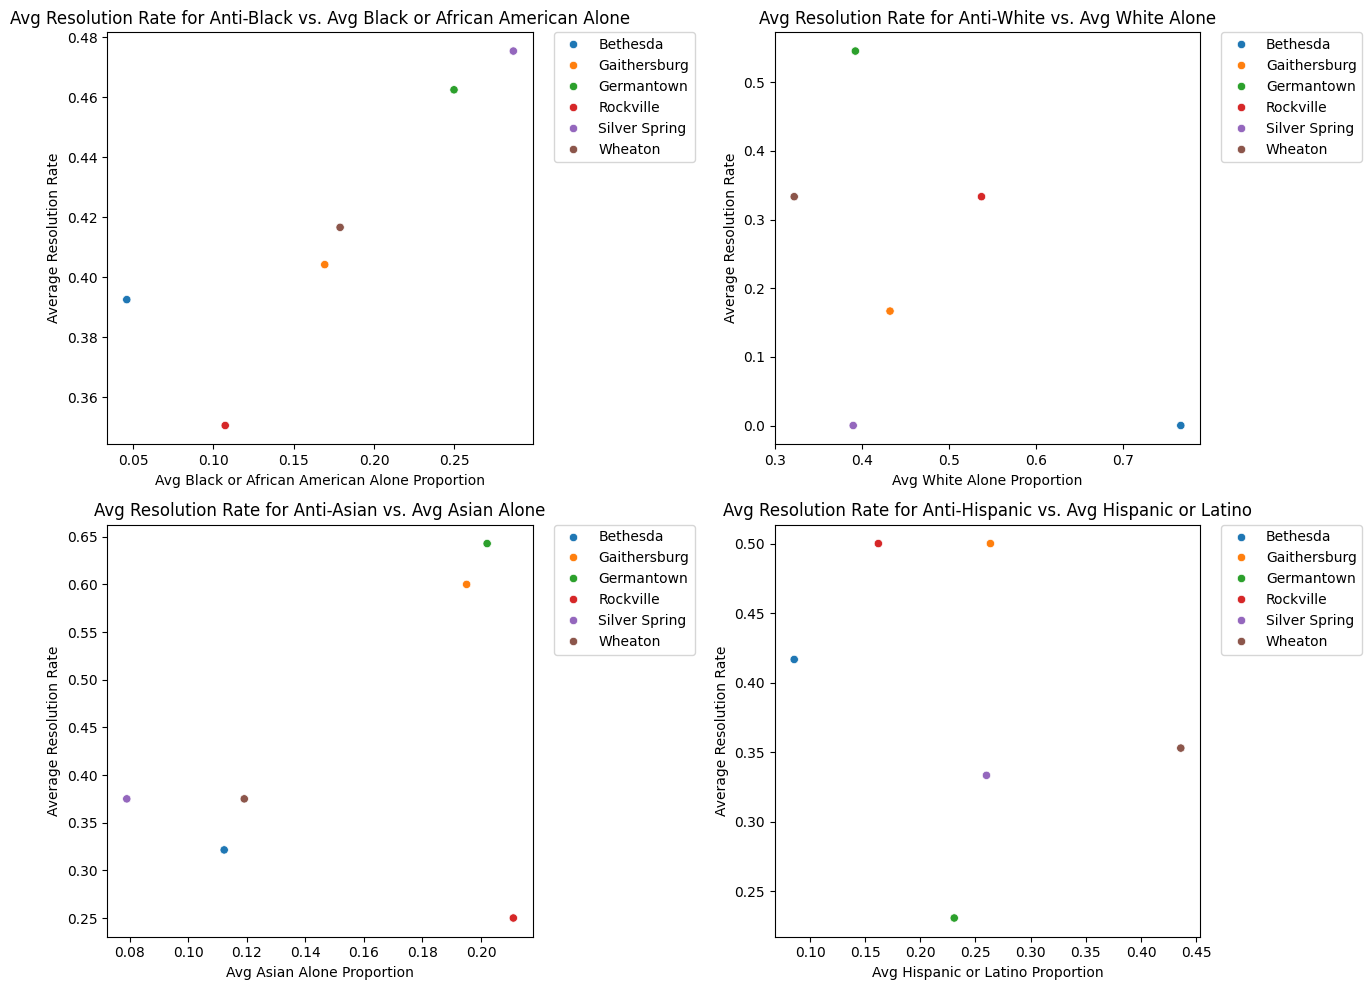


Correlation Summary (Average Bias Resolution Rate vs. Average Corresponding Racial Population Proportion by City):


,Bias Type,ACS Population Category,Pearson Correlation,P-value
0,Anti-Black,Black or African American Alone Proportion,0.862307,0.027134
1,Anti-White,White Alone Proportion,-0.466355,0.351180
2,Anti-Asian,Asian Alone Proportion,0.394578,0.438849
3,Anti-Hispanic,Hispanic or Latino Proportion,-0.276116,0.596352



Limitations for other racial/ethnic bias types (using averaged data):
- 'Anti-Jewish': Jewish identity is ethno-religious and does not map directly to a single racial category in ACS population data for a direct proportion comparison.
- 'Anti-Multi-Racial': ACS has 'Two or More Races', but the bias might be against perceived mixed-race identity, and city-level incident counts might be too low for robust analysis.


In [ ]:
# 1. Prepare City-level Racial Demographic Proportions (Averaged)
# Calculate the average racial demographic data from acs_df across all years for each city
city_demographics_avg_proportions = acs_df.copy()
race_cols = ['White Alone', 'Black or African American Alone', 'Asian Alone', 'Hispanic or Latino']

for col in race_cols:
    city_demographics_avg_proportions[f'{col} Proportion'] = city_demographics_avg_proportions[col] / city_demographics_avg_proportions['Total Population']

# Average these proportions per city across all available years
city_demographics_avg_proportions = city_demographics_avg_proportions.groupby('city')[[
    f'{col} Proportion' for col in race_cols
]].mean().reset_index()

city_demographics_avg_proportions.rename(columns={'city': 'city_x'}, inplace=True)

print("City-level Racial Proportions (Averaged):")
display(city_demographics_avg_proportions.head())

# 2. Calculate City-level Resolution Rates for Racial Bias Types (Averaged)
# Use the df2_merged which contains city and demographic info per incident
racial_ethnic_bias_types = [
    'Anti-Black', 'Anti-White', 'Anti-Asian', 'Anti-Hispanic',
    'Anti-Multi-Racial', 'Anti-Jewish'
]

# Filter df2_merged for these specific bias types and where 'city_x' is not null
city_racial_bias_df_avg = df2_merged[
    df2_merged['bias_code'].isin(racial_ethnic_bias_types) & df2_merged['city_x'].notna()
].copy()

# Calculate average resolution rates per city and bias type across all years
city_racial_bias_resolution_rates_avg = city_racial_bias_df_avg.groupby(['city_x', 'bias_code'])['resolved'].mean().reset_index()
city_racial_bias_resolution_rates_avg.rename(columns={'resolved': 'resolution_rate'}, inplace=True)

print("\nCity-level Racial Bias Resolution Rates (Averaged):")
display(city_racial_bias_resolution_rates_avg.head())

# 3. Merge and Analyze (Focus on directly comparable racial groups first)
# Create a mapping from bias_code to ACS population proportion column
bias_to_acs_map_avg = {
    'Anti-Black': 'Black or African American Alone Proportion',
    'Anti-White': 'White Alone Proportion',
    'Anti-Asian': 'Asian Alone Proportion',
    'Anti-Hispanic': 'Hispanic or Latino Proportion'
}

analysis_data_avg = []

plt.figure(figsize=(15, 10))
plot_idx_avg = 1

for bias_type, acs_proportion_col in bias_to_acs_map_avg.items():
    # Get resolution rates for the current bias type
    res_rates_for_bias_avg = city_racial_bias_resolution_rates_avg[city_racial_bias_resolution_rates_avg['bias_code'] == bias_type]

    # Merge with city demographic proportions
    merged_df_avg = pd.merge(
        res_rates_for_bias_avg,
        city_demographics_avg_proportions,
        on='city_x',
        how='inner'
    )

    if not merged_df_avg.empty:
        # Calculate correlation for this specific bias type across all cities (averaged data)
        corr_avg, p_val_avg = pearsonr(merged_df_avg[acs_proportion_col], merged_df_avg['resolution_rate'])
        analysis_data_avg.append({
            'Bias Type': bias_type,
            'ACS Population Category': acs_proportion_col,
            'Pearson Correlation': corr_avg,
            'P-value': p_val_avg
        })

        # Plotting
        plt.subplot(2, 2, plot_idx_avg) # Create 2x2 grid for plots
        sns.scatterplot(data=merged_df_avg, x=acs_proportion_col, y='resolution_rate', hue='city_x', legend='full')
        plt.title(f'Avg Resolution Rate for {bias_type} vs. Avg {acs_proportion_col.replace(" Proportion", "")}')
        plt.xlabel(f'Avg {acs_proportion_col.replace(" Proportion", "")} Proportion')
        plt.ylabel('Average Resolution Rate')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plot_idx_avg += 1

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for legends
plt.savefig('graphs/averaged_resolution_rate_vs_population_proportion.png') # Save plot
plt.show()

# Display correlations
correlation_summary_df_avg = pd.DataFrame(analysis_data_avg)
print("\nCorrelation Summary (Average Bias Resolution Rate vs. Average Corresponding Racial Population Proportion by City):")
display(correlation_summary_df_avg)

# Discuss limitations for other bias types (same as before)
print("\nLimitations for other racial/ethnic bias types (using averaged data):")
print("- 'Anti-Jewish': Jewish identity is ethno-religious and does not map directly to a single racial category in ACS population data for a direct proportion comparison.")
print("- 'Anti-Multi-Racial': ACS has 'Two or More Races', but the bias might be against perceived mixed-race identity, and city-level incident counts might be too low for robust analysis.")

After averaging the resolution rates and population proportions, it appears only anti-African American cases and its respective average resolution rate is signifcally associated with the average african american population proportion of cities.

This means for anti white, asian, and hispanic cases; there is no correlation to their average resolution rate and average population proportion.

# Summary of Key Findings and Statistical Tests

This analysis investigated various aspects of bias incidents, their resolution rates, demographic factors, and suspect characteristics.

## 1. Z-test for Resolution Rates: Religious vs. Racial/Ethnic Biases
*   **Purpose**: To determine if there's a statistically significant difference in resolution rates between religious and racial/ethnic bias incidents.
*   **Methodology**: Two-sample z-test for proportions, comparing resolution rates of 'Religious Bias' vs. 'Racial/Ethnic Bias' categories.
*   **Finding**: There is a **statistically significant difference** (Z-statistic: -1.98, P-value: 0.0479). Racial bias incidents (40.81% resolved) are **more likely to be resolved** than religious bias incidents (36.22% resolved).

## 2. Chi-square Test (Fisher's Exact Test) for Religious Bias Groups vs. Resolution
*   **Purpose**: To examine if specific religious bias types (grouped) are associated with their likelihood of being resolved.
*   **Methodology**: Fisher's Exact Test applied to a contingency table of grouped religious bias types ('Anti-Jewish' vs. 'Minor Religious Biases') and resolution status.
*   **Finding**: There is **no statistically significant association** (P-value: 0.2246). The likelihood of resolution does not significantly differ between Anti-Jewish incidents and other grouped religious biases.

## 3. Chi-square Tests for Racial/Ethnic Bias Groups vs. Resolution

### a) Including 'Anti-American Indian' (with caution)
*   **Purpose**: To test for an association between specific racial/ethnic bias types (including all observed, even low counts) and resolution status.
*   **Methodology**: Chi-square test of independence.
*   **Finding**: A **statistically significant association** was found (Chi2: 24.93, P-value: 0.0004). However, this finding was noted with **caution** due to 'Anti-American Indian' having very low counts, violating chi-square assumptions.

### b) Excluding 'Anti-American Indian' (robust finding)
*   **Purpose**: To re-evaluate the association between racial/ethnic bias types and resolution status after removing categories with insufficient data (e.g., 'Anti-American Indian').
*   **Methodology**: Chi-square test of independence on filtered data.
*   **Finding**: A **statistically significant association** remains (Chi2: 24.82, P-value: 0.0002). This finding is considered **robust** as it satisfies the test's assumptions, indicating that the specific type of racial/ethnic bias significantly impacts whether an incident is resolved.

## 4. Z-test for Under-18 Suspects in Bias Incidents
*   **Purpose**: To determine if individuals under 18 years old are disproportionately represented as suspects in bias incidents.
*   **Methodology**: One-sample proportions z-test, comparing the observed proportion of under-18 suspects to a null hypothesis of 50%.
*   **Finding**: The test showed a **statistically significant result** (Z-statistic: 10.67, P-value: 0.0000). Individuals below the age of 18 are **disproportionately more likely** to be suspects in bias incidents (65.23% of known-age suspects).

## 5. Pearson's Correlation: Population & Income vs. Average Annual Bias Incidents
*   **Purpose**: To examine the linear relationship between city-level demographics (total population, median household income) and the average annual number of bias incidents.
*   **Methodology**: Pearson's correlation coefficient test.
*   **Finding**:
    *   **Median Household Income**: No statistically significant linear association (Pearson Corr: 0.81, P-value: 0.0518).
    *   **Total Population**: No statistically significant linear association (Pearson Corr: -0.45, P-value: 0.3694).

## 6. ANOVA: Mean Annual Bias Incidents Between Cities
*   **Purpose**: To determine if there are statistically significant differences in the mean annual bias incidents across different cities.
*   **Methodology**: One-Way ANOVA.
*   **Finding**: There is **no statistically significant difference** in the mean annual bias incidents between cities (F-statistic: 2.01, P-value: 0.0942). The observed variations are likely due to random chance.

## 7. Pearson's Correlation: Resolution Rate vs. Racial Population Proportion

### a) Using Yearly Data (Yearly Resolution Rate vs. Yearly Population Proportion)
*   **Purpose**: To find if there's a linear correlation between the yearly resolution rate for specific racial bias types and the yearly population proportion of the corresponding racial group in a city.
*   **Methodology**: Pearson's correlation coefficient test for each racial bias type (Anti-Black, Anti-White, Anti-Asian, Anti-Hispanic) over all years and cities.
*   **Finding**: **No statistically significant correlation** was found for any of the tested racial bias types (Anti-Black P-value: 0.18, Anti-White P-value: 0.65, Anti-Asian P-value: 0.54, Anti-Hispanic P-value: 0.32).

### b) Using Averaged Data (Average Resolution Rate vs. Average Population Proportion)
*   **Purpose**: To find if there's a linear correlation between the *average* resolution rate for specific racial bias types and the *average* population proportion of the corresponding racial group in a city.
*   **Methodology**: Pearson's correlation coefficient test for each racial bias type using averaged data across years.
*   **Finding**:
    *   For **Anti-Black** incidents, there was a **statistically significant positive correlation** (Pearson Corr: 0.86, P-value: 0.0271) between the average resolution rate and the average Black or African American Alone Proportion in cities.
    *   For Anti-White, Anti-Asian, and Anti-Hispanic incidents, **no statistically significant correlation** was found with their respective average population proportions.

---

# Overall Conclusion

This comprehensive analysis reveals several key insights into bias incidents in Montgomery County. While overall city population and median household income do not appear to be significant drivers of the total number of bias incidents, the **type of bias itself is a critical factor in resolution rates**. Racial/ethnic bias incidents have a higher resolution rate than religious ones, and within racial/ethnic categories, there's a significant association between the specific bias type and its resolution likelihood. A notable finding is the **disproportionate involvement of individuals under 18 years old as suspects**. Furthermore, when examining average trends, a **strong positive correlation exists between the average Black population proportion and the average resolution rate of Anti-Black bias incidents in a city**, a pattern not observed for other racial groups. This suggests potential systemic differences in how various bias incidents are processed and resolved, warranting further investigation into the underlying causes of these disparities.